In [1]:
# notebooks/sprint2_model_selection.ipynb

import sys
from pathlib import Path
import numpy as np
import pandas as pd

# ---- Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Paths (consistent with repo)
ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts_lgbm"

# ---- Import model selection utility
sys.path.append(str(ROOT / "src"))
from model_selection_auc import run_model_benchmark


Running Logistic Regression...

Running Random Forest...

Running LightGBM...
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 4539, number of negative: 16826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 21365, number of used features: 62
[LightGBM] [Info]

c:\Projects\Redi\NeuroShot_v.2\neuro_flushot\notebooks\..\src\model_selection_auc.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model", y="macro_auc", palette="viridis")


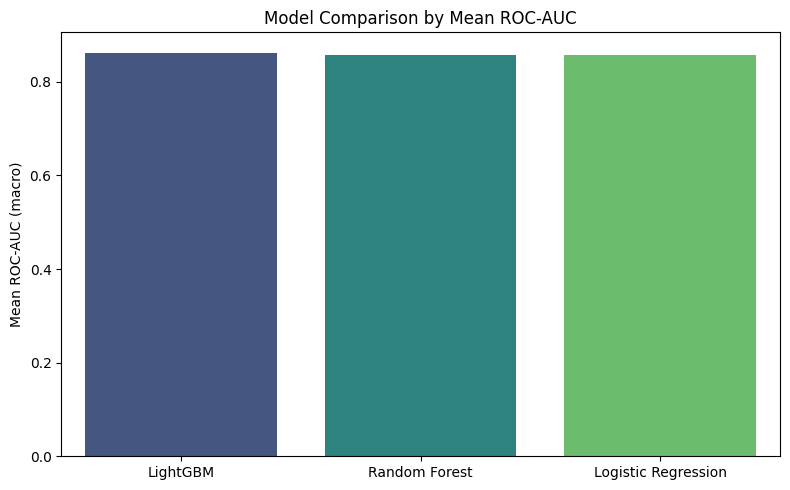

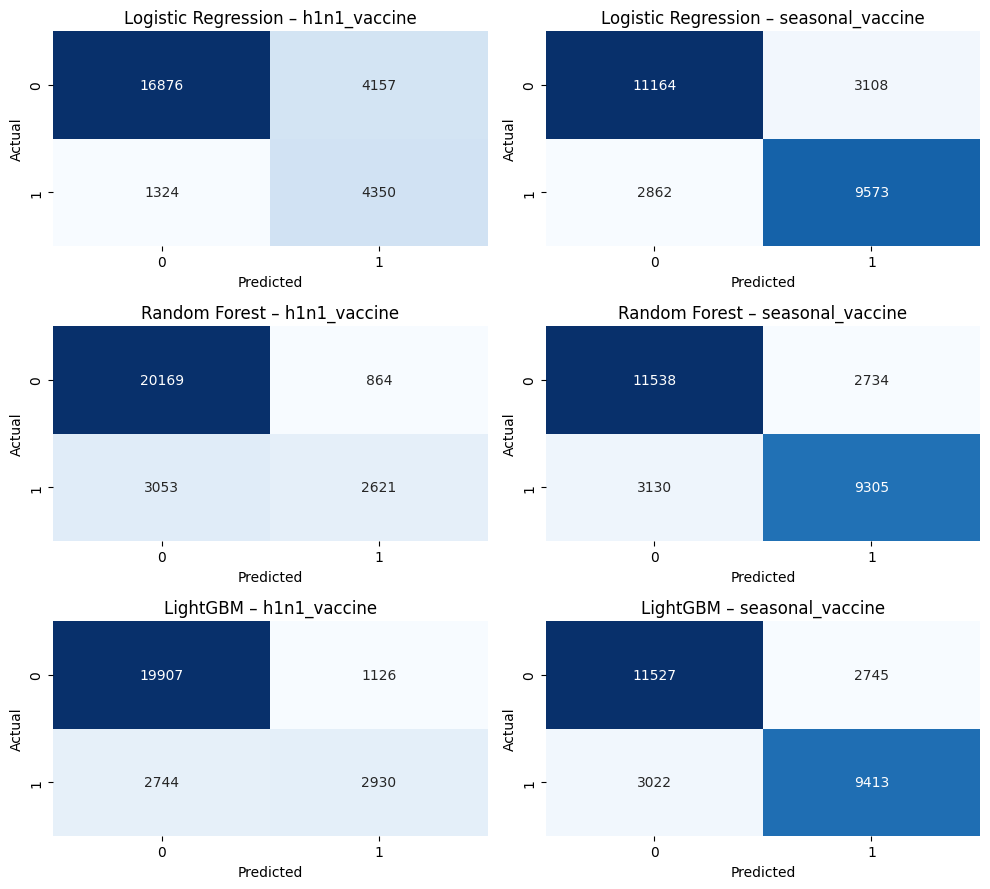


=== Model Comparison by Mean ROC-AUC ===
                 model  h1n1_vaccine  seasonal_vaccine  macro_auc
2             LightGBM         0.865             0.860      0.863
1        Random Forest         0.860             0.854      0.857
0  Logistic Regression         0.861             0.853      0.857


In [2]:
# ---- Run AUC comparison
results_auc = run_model_benchmark(
    train_features_path=str(DATA_TRAIN),
    train_labels_path=str(DATA_LABELS),
    n_splits=5,
    out_dir=str(ARTIFACTS)
)

In [ ]:
# ---- Save results
results_auc.to_csv(ARTIFACTS / "auc_model_comparison.csv", index=False)

### Model Selection Summary

We benchmarked **Logistic Regression**, **Random Forest**, and **LightGBM** using 5-fold cross-validation and **ROC-AUC** as the selection criterion.  
All models showed strong separability, but **LightGBM** achieved the highest macro AUC (0.863), outperforming others by a small but consistent margin.

Confusion matrices confirmed that LightGBM provided the best balance between recall and precision, correctly identifying more vaccinated individuals with minimal false positives.  
Its scalability, flexibility, and native SHAP interpretability make it the most suitable choice for the next modeling phase.

**Decision:** Proceed with **LightGBM** for final tuning, evaluation (F1 optimization), and SHAP explainability.
